<a href="https://colab.research.google.com/github/jhambale/Ab_display_flow_cytometry_stats/blob/main/weighted_average_recalculated_denovo_binding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# load relevant packages

!pip install pysam
!pip install Bio
!pip install dnds
!pip install scipy
!pip install utils

import pandas as pd
import ast
import pysam
from Bio import SeqIO
import glob
import math
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os
from dnds import dnds, pnps
import scipy.stats as stats
from scipy.stats import shapiro
import re

from utils import *
import argparse

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13906 sha256=64e8f6f448eed629842fa6006970ef1baa6cfa97af79b4b7712bf58899385b19
  Stored in directory: /root/.cache/pip/wheels/b6/a1/81/1036477786ae0e17b522f6f5a838f9bc4288d1016fc5d0e1ec
Successfully built utils


In [5]:
# set up directories to which to point

# experiment_id = 'ag_fhab' # user sets this

# stats_df_paths = f'data/{experiment_id}/stats/'

# csv_files = glob.glob(os.path.join(stats_df_paths, f"*.csv"))
# print(csv_files)


from google.colab import files
uploaded = files.upload()


Saving fhab_AG_251017_stats.csv to fhab_AG_251017_stats.csv


In [7]:
stats_df = pd.read_csv('/content/fhab_AG_251017_stats.csv')
#print(stats_df.head())
print(stats_df.columns)


Index(['Plate', 'Experiment', 'Group', 'Filename', 'Sample', 'Workspace',
       'Compensation Source', 'Plot Title', 'Gate', 'Autogate Status',
       'X Parameter', 'Y Parameter', 'Count', 'Volume', 'Concentration',
       '%Total', '%Gated', 'X Mean', 'Y Mean', 'X Median', 'Y Median',
       'X Peak', 'Y Peak', 'X SD', 'Y SD', 'X %CV', 'Y %CV', 'X rSD', 'Y rSD',
       'X %rCV', 'Y %rCV'],
      dtype='object')


In [33]:
stats_important_df = stats_df[['Sample', 'Gate', '%Gated', 'X Mean', 'X Median', 'Count']].copy()
print(stats_important_df)


             Sample        Gate   %Gated    X Mean  X Median   Count
0     r1ni_2000nMAg  All Events  100.000       NaN       NaN  110000
1     r1ni_2000nMAg          R1   98.556      64.0      49.0  108412
2     r1ni_2000nMAg          R2   96.834  302099.0  252165.0  104980
3     r1ni_2000nMAg          R1   98.556  312266.0  256581.0  108412
4     r1ni_2000nMAg          R3   81.561  254654.0  229390.0   85623
...             ...         ...      ...       ...       ...     ...
1147        r7_NoAg          R5   71.991    5187.0    4573.0   53309
1148        r7_NoAg          R3   77.848    3800.0    3240.0   74050
1149        r7_NoAg          R3   77.848      74.0      70.0   74050
1150        r7_NoAg          R7    0.000       NaN       NaN       0
1151        r7_NoAg          R3   77.848      74.0      70.0   74050

[1152 rows x 6 columns]


In [34]:
#view table
stats_important_df

,Sample,Gate,%Gated,X Mean,X Median,Count
0,r1ni_2000nMAg,All Events,100.000,NaN,NaN,110000
1,r1ni_2000nMAg,R1,98.556,64.0,49.0,108412
2,r1ni_2000nMAg,R2,96.834,302099.0,252165.0,104980
3,r1ni_2000nMAg,R1,98.556,312266.0,256581.0,108412
4,r1ni_2000nMAg,R3,81.561,254654.0,229390.0,85623
...,...,...,...,...,...,...
1147,r7_NoAg,R5,71.991,5187.0,4573.0,53309
1148,r7_NoAg,R3,77.848,3800.0,3240.0,74050
1149,r7_NoAg,R3,77.848,74.0,70.0,74050
1150,r7_NoAg,R7,0.000,NaN,NaN,0


In [13]:
sample_list = list(set(stats_important_df['Sample']))
print(len(sample_list))

48


In [38]:
# calculate weighted average
samples_dict = {}
cell_name_list = []
ag_conc_list = []
all_binding_dfs = []

for sample in sample_list:
    # Split sample into parts
    sample_split = sample.split('_')
    cell_name = sample_split[0]

    # Extract numeric concentration after '_'
    conc_part = sample_split[1]
    match = re.search(r'(\d+)', conc_part)
    ag_conc = float(match.group(1)) if match else 0.0

    # Track lists
    cell_name_list.append(cell_name)
    ag_conc_list.append(ag_conc)

    # Filter dataframe for current sample
    sample_stats_df = stats_important_df[stats_important_df['Sample'] == sample]

    # Pivot table for both X Mean and Count
    sample_pivot_df = sample_stats_df.pivot_table(
        index='Sample',
        columns='Gate',
        values=['X Mean', 'Count'],
        aggfunc='first'
    )

    # combine mean and gate info into  a single column
    sample_pivot_df.columns = [f"{val}_{gate}" for val, gate in sample_pivot_df.columns]

    # Gates of interest
    quads_gates = ['-/-(1)', '-/+(1)', '+/-(1)', '+/+(1)']

    # Create binding dataframe
    sample_binding_df = pd.DataFrame()
    for gate in quads_gates:
        sample_binding_df[f"{gate}_XMean"] = sample_pivot_df[f"X Mean_{gate}"]
        sample_binding_df[f"{gate}_Count"] = sample_pivot_df[f"Count_{gate}"]

    # Compute weighted mean fluorescence (onbindnorm) for desired gates
    gates_for_binding = ['+/+(1)', '-/+(1)']
    weighted_sum_bind = sum(sample_binding_df[f"{g}_XMean"] * sample_binding_df[f"{g}_Count"] for g in gates_for_binding)
    total_counts_bind = sum(sample_binding_df[f"{g}_Count"] for g in gates_for_binding)
    sample_binding_df['onbindnorm'] = (weighted_sum_bind / total_counts_bind).clip(lower=0)

    gates_for_sticky = ['-/-(1)', '+/-(1)']
    weighted_sum_sticky = sum(sample_binding_df[f"{g}_XMean"] * sample_binding_df[f"{g}_Count"] for g in gates_for_sticky)
    total_counts_sticky = sum(sample_binding_df[f"{g}_Count"] for g in gates_for_binding)
    sample_binding_df['sticky'] = (weighted_sum_sticky / total_counts_sticky).clip(lower=0)

    # Add metadata
    sample_binding_df['Sample'] = sample
    sample_binding_df['cell_name'] = cell_name
    sample_binding_df['concentration_nM'] = ag_conc

    # Save to dict and list
    samples_dict[sample] = sample_binding_df
    all_binding_dfs.append(sample_binding_df)

# Combine all samples
sample_binding_df = pd.concat(all_binding_dfs).reset_index(drop=True)

# Remove unwanted sample
sample_binding_df = sample_binding_df[sample_binding_df['cell_name'] != 'r1ni']



['r3', 'r1', 'r5', 'r4', 'r1ni', 'r2', 'r7', 'r6']
[0.0, 7.0, 2000.0, 500.0, 120.0, 125.0, 31.0]


In [39]:
sample_binding_df

,-/-(1)_XMean,-/-(1)_Count,-/+(1)_XMean,-/+(1)_Count,+/-(1)_XMean,+/-(1)_Count,+/+(1)_XMean,+/+(1)_Count,onbindnorm,sticky,Sample,cell_name,concentration_nM
0,56.0,20764,75.0,54227,612.0,33,538.0,640,80.400696,21.560865,r2_125nMAg,r2,125.0
1,61.0,19200,81.0,49235,554.0,28,357.0,706,84.901724,23.762279,r4_31nMAg,r4,31.0
2,60.0,18824,79.0,50699,2559.0,23,581.0,440,83.319208,23.236610,r1_7nMAg,r1,7.0
3,60.0,18519,81.0,48191,372.0,22,326.0,564,83.834171,22.958138,r4_7nMAg,r4,7.0
4,60.0,20467,78.0,54747,1587.0,34,331.0,402,79.844204,23.245716,r3_7nMAg,r3,7.0
5,72.0,19452,97.0,52895,1767.0,96,636.0,1880,115.499681,28.665924,r3_2000nMAg,r3,2000.0
6,61.0,19324,77.0,52831,2753.0,82,501.0,816,83.449270,26.180588,r7_500nMAg,r7,500.0
7,61.0,19946,77.0,53732,303.0,14,308.0,358,78.528896,22.572527,r7_NoAg,r7,0.0
8,56.0,20750,74.0,50219,1446.0,213,978.0,2116,110.550377,28.088239,r1_2000nMAg,r1,2000.0
9,62.0,18844,80.0,48690,535.0,94,609.0,1061,91.281562,24.494342,r5_500nMAg,r5,500.0


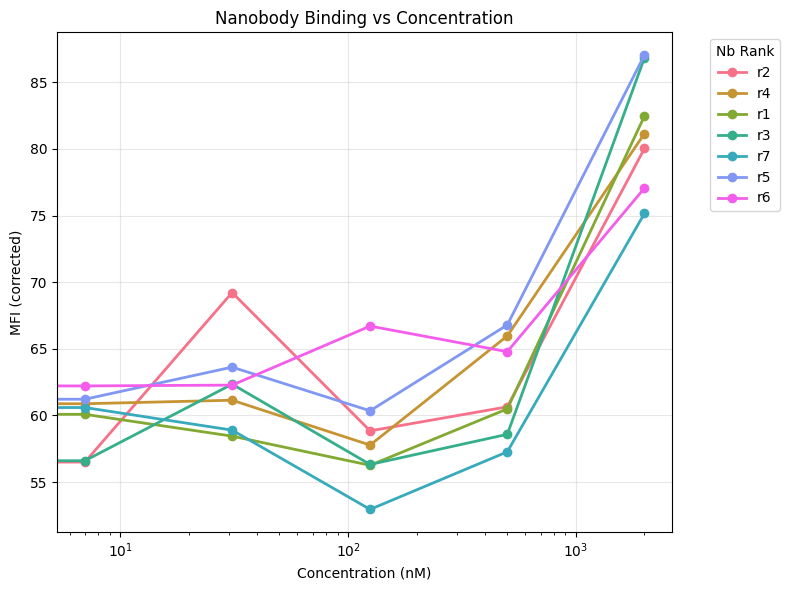

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute corrected binding for plotting
sample_binding_df['binding_minus_sticky'] = (
    sample_binding_df['onbindnorm'] - sample_binding_df['sticky']
).clip(lower=0)

# Define unique cell names
cell_names = sample_binding_df['cell_name'].unique()

# Define color palette
colors = sns.color_palette("husl", len(cell_names))

# Create plot
plt.figure(figsize=(8, 6))
for idx, cell in enumerate(cell_names):
    df_cell = sample_binding_df[sample_binding_df['cell_name'] == cell]
    df_cell = df_cell.sort_values('concentration_nM')

    x = df_cell['concentration_nM']
    y = df_cell['binding_minus_sticky']  # scale for readability (optional)

    plt.plot(x, y,
             marker='o',
             color=colors[idx],
             label=cell,
             linewidth=2)

# Set scales, labels, and style
plt.xscale('log')
plt.xlabel('Concentration (nM)')
plt.ylabel('MFI (corrected)')
plt.title('Nanobody Binding vs Concentration')
plt.legend(title='Nb Rank', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig('binding_vs_concentration_allcells.png', dpi=600, bbox_inches='tight')
plt.show()
